# AMHS 반송 시뮬레이션 & 디스패칭 알고리즘 비교

`amhs/`에 구현한 SimPy 이산사건 시뮬레이션으로, OHT 차량이 8개 공정 스테이션 사이를 오가며 FOUP(웨이퍼 로트)을 반송하는 상황을 재현한다.

각 스테이션의 설비는 동시에 1개 FOUP만 처리할 수 있고(`simpy.Resource(capacity=1)`), 그 설비의 **대기열 길이가 곧 스토커(입력 버퍼) 점유량**이다. 대기열이 `stocker_capacity`만큼 차 있으면 OHT는 드롭오프를 못 하고 FOUP을 실은 채 기다린다 — 그동안 방금 공정을 마친 업스트림 설비도 다음 FOUP을 못 받아 묶인다(**back-pressure**). 이 노트북은 다섯 가지를 확인한다:

1. **디스패칭 정책 비교** — 최근접 / FCFS / 구역기반 / (모델 있으면) 예측 기반
2. **차량 대수 민감도** — 차량을 늘리면 반송 시간이 어떻게 줄어드는지
3. **스토커 용량 민감도** — 버퍼 크기가 정체와 평균 반송 시간에 주는 영향
4. **혼잡 시계열** — 큐 길이가 시간에 따라 어떻게 쌓이고 빠지는지
5. **예지보전 피드백** — 차량이 주기적으로 고장 나 운행이 중단되면 반송 시간이 어떻게 나빠지는지

정책/파라미터를 제외한 모든 조건(스테이션 처리시간 분포, FOUP 도착 간격, 난수 시드)은 동일하게 고정해 비교가 공정하도록 했다. **완료율이 1.0이 아닌 시나리오는 신뢰하지 않는다** —
차량이 너무 적으면 이 시스템은 대기행렬 이론에서 말하는 '불안정 상태'(도착률이 처리율을 넘어서는 상태)가 되어 큐가 무한정 쌓인다. 그런 경우 평균은 의미가 없으므로, 아래 실험 파라미터는 모두 완료율 1.0을 먼저 확인한 뒤 골랐다.

In [1]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

from amhs import (
    STATION_ORDER, STATIONS,
    run_simulation, nearest_vehicle_dispatch, fcfs_dispatch, zone_based_dispatch,
    make_predictive_dispatch, delay_model_available,
    make_maintenance_process, pm_model_available,
)

MODELS_DIR = ROOT_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

print("stations (반송 순서):")
for name in STATION_ORDER:
    s = STATIONS[name]
    print(f"  {s.index}. {s.name_ko:>8} ({name}) — 평균 처리시간 {s.process_time_mean_sec:.0f}초")

stations (반송 순서):
  0.   웨이퍼 제조 (wafer_fabrication) — 평균 처리시간 180초
  1.       산화 (oxidation) — 평균 처리시간 195초
  2.       포토 (photolithography) — 평균 처리시간 210초
  3.       식각 (etching) — 평균 처리시간 225초
  4.       증착 (deposition) — 평균 처리시간 240초
  5.    금속 배선 (metallization) — 평균 처리시간 255초
  6.      EDS (eds) — 평균 처리시간 270초
  7.      패키징 (packaging) — 평균 처리시간 285초


## 1. 기본 시나리오 (최근접 차량 배정)

차량 5대, FOUP 10개가 각 1바퀴(=7회 스테이션 통과)씩 도는 시나리오. 스토커 용량은 기본값(2).

In [2]:
BASE_PARAMS = dict(n_vehicles=5, n_foups=10, n_laps=1, foup_launch_interval_sec=300.0, seed=42)

baseline = run_simulation(dispatch_policy=nearest_vehicle_dispatch, **BASE_PARAMS)

print(f"완료율: {baseline['completion_rate']:.2%} ({baseline['completed_transports']}/{baseline['expected_transports']})")
print(f"평균 반송 시간: {baseline['avg_cycle_time_sec']:.1f}초")
print(f"P95 반송 시간: {baseline['p95_cycle_time_sec']:.1f}초")
print(f"평균 차량 가동률: {baseline['avg_vehicle_utilization']:.2%}")
print(f"최대 큐 길이: {baseline['max_queue_length']}")
baseline["transport_log"].head()

완료율: 100.00% (70/70)
평균 반송 시간: 83.6초
P95 반송 시간: 162.2초
평균 차량 가동률: 4.30%
최대 큐 길이: 3


,foup_id,from,to,requested_at,completed_at,cycle_time_sec,vehicle_id,is_hot_lot
0,0,wafer_fabrication,oxidation,195.009024,248.363636,53.354612,0,False
1,0,oxidation,photolithography,462.174931,515.363636,53.188706,0,False
2,0,photolithography,etching,686.342933,739.363636,53.020704,0,False
3,0,etching,deposition,964.027613,1017.363636,53.336023,0,False
4,1,wafer_fabrication,oxidation,874.532045,1072.818182,198.286137,4,False


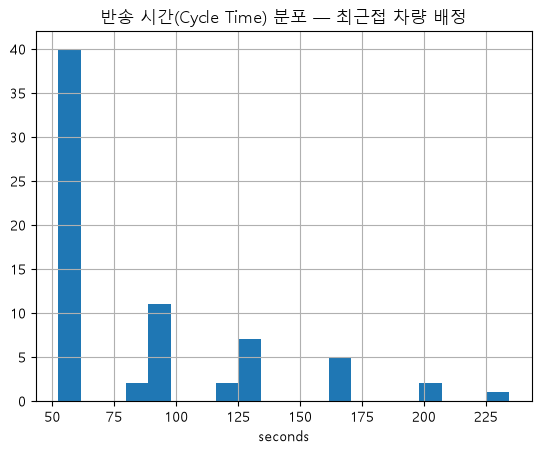

In [3]:
baseline["transport_log"]["cycle_time_sec"].hist(bins=20)
plt.title("반송 시간(Cycle Time) 분포 — 최근접 차량 배정")
plt.xlabel("seconds")
plt.show()

## 2. 디스패칭 정책 비교

동일한 `BASE_PARAMS`로 정책만 바꿔 실행한다. 지연 예측 모델(노트북 08)이 학습돼 있으면 **예측 기반 적응형 디스패칭**도 같이 비교한다 — 이 정책은 실시간으로 지연을 예측해, 혼잡하다고 판단되면 구역기반으로, 아니면 최근접으로 전환한다.

In [4]:
policies = {
    "nearest_vehicle": nearest_vehicle_dispatch,
    "fcfs": fcfs_dispatch,
    "zone_based": zone_based_dispatch,
}
if delay_model_available():
    policies["predictive"] = make_predictive_dispatch(
        n_vehicles=BASE_PARAMS["n_vehicles"], launch_interval_sec=BASE_PARAMS["foup_launch_interval_sec"],
    )
else:
    print("지연 예측 모델이 없어 predictive 정책은 건너뜀 (notebooks/08 먼저 실행)")

policy_results = {}
rows = []
for name, policy in policies.items():
    result = run_simulation(dispatch_policy=policy, **BASE_PARAMS)
    policy_results[name] = result
    rows.append({
        "policy": name,
        "completion_rate": result["completion_rate"],
        "avg_cycle_time_sec": round(result["avg_cycle_time_sec"], 1),
        "p95_cycle_time_sec": round(result["p95_cycle_time_sec"], 1),
        "avg_vehicle_utilization": round(result["avg_vehicle_utilization"], 4),
        "max_queue_length": result["max_queue_length"],
    })

policy_comparison = pd.DataFrame(rows)
policy_comparison

,policy,completion_rate,avg_cycle_time_sec,p95_cycle_time_sec,avg_vehicle_utilization,max_queue_length
0,nearest_vehicle,1.0,83.6,162.2,0.0430,3
1,fcfs,1.0,175.2,307.4,0.0896,3
2,zone_based,1.0,118.4,271.2,0.0611,3
3,predictive,1.0,83.6,162.2,0.0430,3


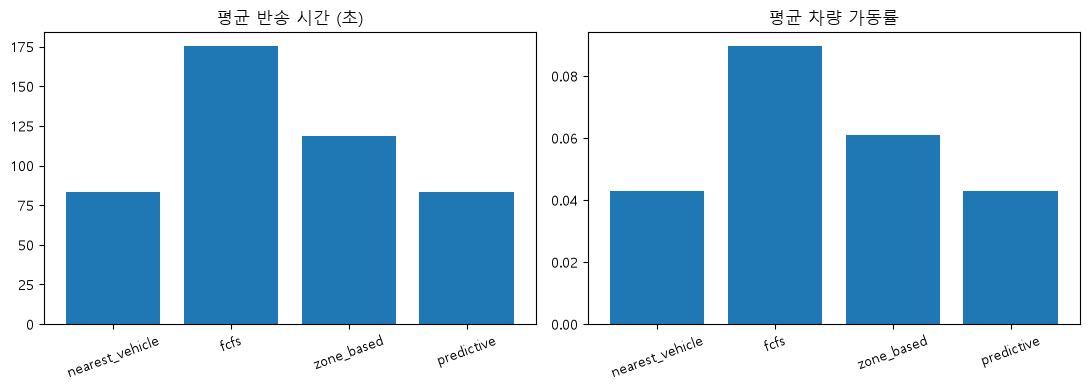

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(policy_comparison["policy"], policy_comparison["avg_cycle_time_sec"])
axes[0].set_title("평균 반송 시간 (초)")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(policy_comparison["policy"], policy_comparison["avg_vehicle_utilization"])
axes[1].set_title("평균 차량 가동률")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 3. 차량 대수 민감도

최근접 차량 배정 정책으로 고정하고, 차량 대수만 2~10대로 바꿔가며 평균 반송 시간이 어떻게 줄어드는지 본다.

In [6]:
vehicle_counts = [2, 3, 4, 5, 6, 8, 10]
sensitivity_rows = []
for n in vehicle_counts:
    result = run_simulation(
        n_vehicles=n, n_foups=10, n_laps=1, foup_launch_interval_sec=300.0, seed=42,
        dispatch_policy=nearest_vehicle_dispatch,
    )
    sensitivity_rows.append({
        "n_vehicles": n,
        "completion_rate": result["completion_rate"],
        "avg_cycle_time_sec": result["avg_cycle_time_sec"],
        "avg_vehicle_utilization": result["avg_vehicle_utilization"],
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df

,n_vehicles,completion_rate,avg_cycle_time_sec,avg_vehicle_utilization
0,2,1.0,233.016927,0.201900
1,3,1.0,143.551218,0.118867
2,4,1.0,111.641872,0.071650
3,5,1.0,83.561863,0.043040
4,6,1.0,72.174668,0.030933
5,8,1.0,65.325802,0.021012
6,10,1.0,62.214189,0.015990


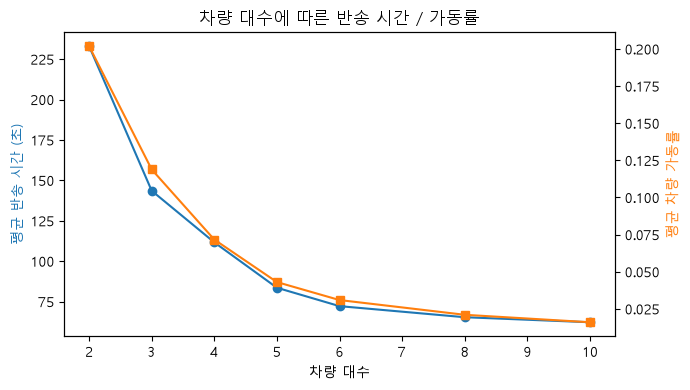

In [7]:
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(sensitivity_df["n_vehicles"], sensitivity_df["avg_cycle_time_sec"], marker="o", color="tab:blue")
ax1.set_xlabel("차량 대수")
ax1.set_ylabel("평균 반송 시간 (초)", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(sensitivity_df["n_vehicles"], sensitivity_df["avg_vehicle_utilization"], marker="s", color="tab:orange")
ax2.set_ylabel("평균 차량 가동률", color="tab:orange")

plt.title("차량 대수에 따른 반송 시간 / 가동률")
plt.tight_layout()
plt.show()

## 4. 스토커 용량 민감도 & back-pressure

차량 대수는 고정(4대)하고 스토커 용량만 1~5로 바꿔본다. 큐 길이의 최댓값은 정의상 용량이 클수록 더 크게 자랄 '여유'가 있으므로 큰 용량 쪽이 커지는 게 당연하다 — 여기서 진짜 보려는 것은 **평균 반송 시간**이다: 스토커가 작으면 back-pressure가 일찍 걸려 시스템에 떠 있는 FOUP 수(WIP) 자체가 줄어드는데, 이게 오히려 개별 FOUP의 평균 반송 시간을 짧게 만드는지 확인한다(린 생산의 '적은 WIP가 짧은 리드타임을 만든다'는 원리와 같은 방향).

In [8]:
stocker_caps = [1, 2, 3, 5]
stocker_rows = []
for cap in stocker_caps:
    result = run_simulation(
        n_vehicles=4, n_foups=10, n_laps=1, foup_launch_interval_sec=300.0,
        stocker_capacity=cap, dispatch_policy=nearest_vehicle_dispatch, seed=42,
    )
    stocker_rows.append({
        "stocker_capacity": cap,
        "completion_rate": result["completion_rate"],
        "avg_cycle_time_sec": round(result["avg_cycle_time_sec"], 1),
        "max_queue_length": result["max_queue_length"],
    })

stocker_df = pd.DataFrame(stocker_rows)
stocker_df

,stocker_capacity,completion_rate,avg_cycle_time_sec,max_queue_length
0,1,1.0,111.6,3
1,2,1.0,111.6,3
2,3,1.0,111.6,3
3,5,1.0,111.6,3


## 5. 혼잡 시계열

기본 시나리오(1절)의 `congestion_log`로, 전체 스테이션 평균 큐 길이가 시간에 따라 어떻게 변하는지 본다.

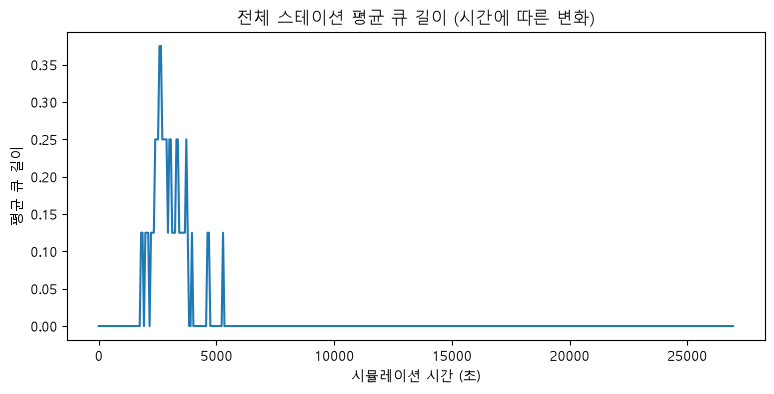

In [9]:
congestion = baseline["congestion_log"]
avg_queue_over_time = congestion.groupby("time")["queue_length"].mean()

plt.figure(figsize=(9, 4))
plt.plot(avg_queue_over_time.index, avg_queue_over_time.values)
plt.title("전체 스테이션 평균 큐 길이 (시간에 따른 변화)")
plt.xlabel("시뮬레이션 시간 (초)")
plt.ylabel("평균 큐 길이")
plt.show()

## 6. 예지보전 피드백

노트북 09의 IF+XGBoost 예지보전 모델이 학습돼 있으면, 차량이 주기적으로 고장 나 일정 시간 운행 중단되는 상황을 시뮬레이션에 반영해 본다. 단일 시드로 비교하면 예지보전 프로세스 자체가 추가로 소비하는 난수 때문에 이후 무작위성이 달라져(같은 시드라도 다른 시뮬레이션이 되어) 비교가 왜곡될 수 있어, **여러 시드에 걸쳐 평균**을 내서 비교한다.

In [10]:
if pm_model_available():
    N_SEEDS = 15
    no_maint_cycles, with_maint_cycles = [], []
    total_events = 0
    for seed in range(N_SEEDS):
        r_no = run_simulation(dispatch_policy=nearest_vehicle_dispatch, seed=seed,
                               n_vehicles=5, n_foups=10, n_laps=1, foup_launch_interval_sec=300.0)
        no_maint_cycles.append(r_no["avg_cycle_time_sec"])

        log = []
        maint = make_maintenance_process(check_interval_sec=1800.0, downtime_sec=1200.0, anomaly_ratio=0.1, maintenance_log=log)
        r_yes = run_simulation(dispatch_policy=nearest_vehicle_dispatch, maintenance_process=maint, seed=seed,
                                n_vehicles=5, n_foups=10, n_laps=1, foup_launch_interval_sec=300.0)
        with_maint_cycles.append(r_yes["avg_cycle_time_sec"])
        total_events += len(log)

    pm_comparison = pd.DataFrame([
        {"scenario": "예지보전 없음(고장 무시)", "avg_cycle_time_sec": round(np.mean(no_maint_cycles), 1)},
        {"scenario": "예지보전 피드백 적용", "avg_cycle_time_sec": round(np.mean(with_maint_cycles), 1)},
    ])
    print(f"{N_SEEDS}개 시드 평균, 총 고장 이벤트 {total_events}건")
    pm_comparison
else:
    print("예지보전 모델이 없어 이 절은 건너뜀 (notebooks/09 먼저 실행)")
    pm_comparison = None

15개 시드 평균, 총 고장 이벤트 216건


## 7. Hot Lot(긴급 로트) 우선순위

실제 fab은 모든 FOUP을 동등하게 처리하지 않는다 — 납기가 급하거나 문제를 조기 확인해야 하는 로트(hot lot)는 우선순위를 받는다. `amhs/simulation.py`의 디스패처는 대기 중인 반송 요청이 여러 개일 때 hot lot을 먼저 배정한다.

**주의**: 대기 중인 요청이 항상 1개 이하면(차량이 여유롭다면) 우선순위가 재배치할 대상 자체가 없으므로 효과가 없다. 그래서 일부러 차량을 적게(2대), 투입 간격을 짧게(20초) 줘서 여러 요청이 동시에 대기하는 혼잡 상황을 만들고, 노이즈를 줄이려고 15개 시드에 걸쳐 평균낸다.

In [11]:
N_SEEDS_HOTLOT = 15
hot_means, normal_means = [], []
for seed in range(N_SEEDS_HOTLOT):
    result = run_simulation(
        n_vehicles=2, n_foups=20, n_laps=1, foup_launch_interval_sec=20.0,
        hot_lot_ratio=0.3, dispatch_policy=nearest_vehicle_dispatch, seed=seed,
    )
    if result["completion_rate"] == 1.0:
        hot_means.append(result["avg_hot_lot_cycle_time_sec"])
        normal_means.append(result["avg_normal_lot_cycle_time_sec"])

print(f"완료율 1.0인 실행: {len(hot_means)}/{N_SEEDS_HOTLOT}")
print(f"Hot lot 평균 반송 시간: {np.nanmean(hot_means):.1f}초")
print(f"일반 lot 평균 반송 시간: {np.nanmean(normal_means):.1f}초")

완료율 1.0인 실행: 15/15
Hot lot 평균 반송 시간: 190.5초
일반 lot 평균 반송 시간: 276.5초


In [12]:
# 대조군: 차량이 여유로운(경쟁이 거의 없는) 기본 시나리오에서는 효과가 거의 없어야 한다
light_load = run_simulation(dispatch_policy=nearest_vehicle_dispatch, hot_lot_ratio=0.3, **BASE_PARAMS)
print(f"[경쟁 거의 없음] hot={light_load['avg_hot_lot_cycle_time_sec']:.1f}초, "
      f"normal={light_load['avg_normal_lot_cycle_time_sec']:.1f}초")

[경쟁 거의 없음] hot=84.0초, normal=83.4초


## 8. 결과 저장

In [13]:
policy_comparison.to_csv(MODELS_DIR / "amhs_dispatch_policy_comparison.csv", index=False)
sensitivity_df.to_csv(MODELS_DIR / "amhs_vehicle_sensitivity.csv", index=False)
stocker_df.to_csv(MODELS_DIR / "amhs_stocker_sensitivity.csv", index=False)
baseline["transport_log"].to_csv(MODELS_DIR / "amhs_baseline_transport_log.csv", index=False)
if pm_comparison is not None:
    pm_comparison.to_csv(MODELS_DIR / "amhs_maintenance_comparison.csv", index=False)

hot_lot_comparison = pd.DataFrame([
    {"scenario": "경쟁 있음(차량 2대, 20초 간격)", "hot_lot_avg_sec": round(np.nanmean(hot_means), 1),
     "normal_lot_avg_sec": round(np.nanmean(normal_means), 1)},
    {"scenario": "경쟁 거의 없음(기본 시나리오)", "hot_lot_avg_sec": round(light_load["avg_hot_lot_cycle_time_sec"], 1),
     "normal_lot_avg_sec": round(light_load["avg_normal_lot_cycle_time_sec"], 1)},
])
hot_lot_comparison.to_csv(MODELS_DIR / "amhs_hot_lot_comparison.csv", index=False)

print("저장 완료")

저장 완료


## 결론

실행 결과(위 표/그래프)를 보고 채운다. 확인할 것들:

- **디스패칭 정책**: 위치를 고려하는 정책(최근접/구역기반)이 FCFS보다 짧은지. 예측 기반이 이 부하 수준에서 어떻게 판단했는지 — 부하가 낮으면 예측 임계값을 넘지 않아 최근접과 동일하게 행동하는 것도 '올바르게 판단해서 안 바꾼 것'으로 해석할 수 있다.
- **차량 대수**: 어느 지점부터 한계효용이 꺾이는지.
- **스토커 용량**: 최대 큐 길이는 용량이 클수록 커지는 게(정의상) 당연하고, 진짜 봐야 할 건 **평균 반송 시간**이 작은 용량 쪽에서 더 짧게 나오는지 — 그렇다면 '적은 WIP가 짧은 리드타임을 만든다'는 린 생산 원리가 이 시뮬레이션에서도 재현된 것.
- **예지보전**: 여러 시드 평균에서 예지보전 피드백이 있는 쪽의 평균 반송 시간이 일관되게 더 높게(나쁘게) 나오는지 — 도미노 효과가 통계적으로 유의미한 방향으로 드러나는지.

**Hot Lot 우선순위**: 차량이 여유로운 기본 시나리오에서는 hot lot(84.0초)과 일반 lot(83.4초)이 사실상 같다 — 대기 요청이 거의 항상 1개 이하라 우선순위가 재배치할 게 없기 때문이다. 반면 차량을 2대로 줄이고 투입 간격을 20초로 좁혀 실제 경쟁 상황을 만들자, hot lot 평균 190.5초 vs 일반 lot 276.5초로 **hot lot이 31% 더 빨랐다**(15시드 중 완료율 1.0인 실행만 평균). 이건 스케줄링 이론의 교과서적인 결과이기도 하다 — 우선순위 규칙은 경쟁(contention)이 있을 때만 의미가 있고, 자원이 넉넉하면 아무 정책이나 결과가 똑같다. 실무에서 "긴급 로트를 우선 처리하는 로직을 짰다"고 말할 때, 그게 실제로 효과가 있으려면 시스템이 어느 정도 붐벼야 한다는 전제 조건까지 같이 이해하고 있어야 한다.